In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from tobii_pytracker.analyze.data_loader import DataLoader
from tobii_pytracker.configs.custom_config import CustomConfig

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from tobii_pytracker.analyze.models import (
    HeatmapAnalyzer,
    FocusMapAnalyzer,
    FixationAnalyzer,
    SaccadeAnalyzer,
    EntropyAnalyzer,
    ClusterAnalyzer,
    ConceptAnalyzer,
    ScanpathsAnalyzer,
    VoiceTranscription,
    BBoxAttentionAnalyzer
)


config = CustomConfig('../configs/config.yaml')
loader = DataLoader(config, root='../')

▶ Global heatmap statistics


,avg_gaze_x,avg_gaze_y,gaze_count
0,-33.927971,-27.411219,2870


▶ Per-set statistics


,set_name,avg_gaze_x,avg_gaze_y,gaze_count
0,20260712_223029,-33.927971,-27.411219,2870


▶ Per-slide statistics


,set_name,slide_index,avg_gaze_x,avg_gaze_y,gaze_count
0,20260712_223029,0,14.440979,82.417049,603
1,20260712_223029,1,-50.982220,-78.363551,232
2,20260712_223029,2,-95.261036,-35.492468,292
3,20260712_223029,3,31.619040,-98.047077,329
4,20260712_223029,4,-109.304766,17.036152,200


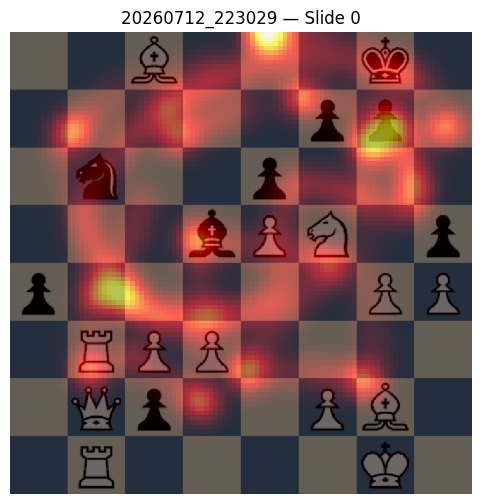

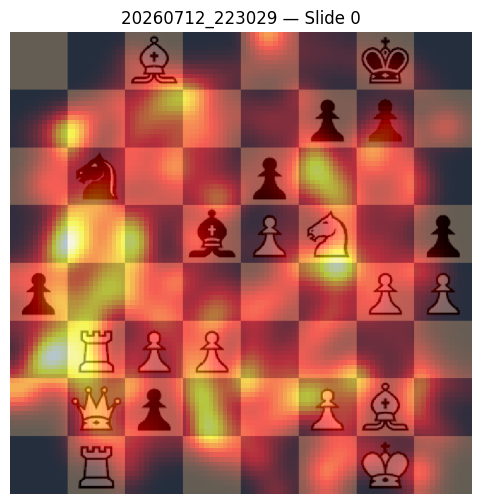

In [3]:
# Assuming you already have the data
background_data = pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

analyzer = HeatmapAnalyzer(output_folder=output_dir)

# --- Global ---
print("▶ Global heatmap statistics")
global_stats = analyzer.analyze(background_data, per="global")
display(global_stats)

# --- Set-level ---
print("▶ Per-set statistics")
set_stats = analyzer.analyze(background_data, per="set")
display(set_stats.head())

# --- Slide-level ---
print("▶ Per-slide statistics")
slide_stats = analyzer.analyze(background_data, per="slide")
display(slide_stats.head())

# --- Plot heatmap for one image ---
example_slide = background_data.iloc[0]
subset = background_data[
    (background_data["set_name"] == example_slide["set_name"]) &
    (background_data["slide_index"] == example_slide["slide_index"])
]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

analyzer.plot_analysis(
    background_data=subset,
    screenshot_path=screenshot_path,
    title=f"{example_slide['set_name']} — Slide {example_slide['slide_index']}",
)


analyzer.plot_analysis(
    background_data=background_data,
    screenshot_path=screenshot_path,
    title=f"{example_slide['set_name']} — Slide {example_slide['slide_index']}",
)


▶ Global focus map statistics


,avg_gaze_x,avg_gaze_y,gaze_count
0,-33.927971,-27.411219,2870


▶ Per-set statistics


,set_name,avg_gaze_x,avg_gaze_y,gaze_count
0,20260712_223029,-33.927971,-27.411219,2870


▶ Per-slide statistics


,set_name,slide_index,avg_gaze_x,avg_gaze_y,gaze_count
0,20260712_223029,0,14.440979,82.417049,603
1,20260712_223029,1,-50.982220,-78.363551,232
2,20260712_223029,2,-95.261036,-35.492468,292
3,20260712_223029,3,31.619040,-98.047077,329
4,20260712_223029,4,-109.304766,17.036152,200


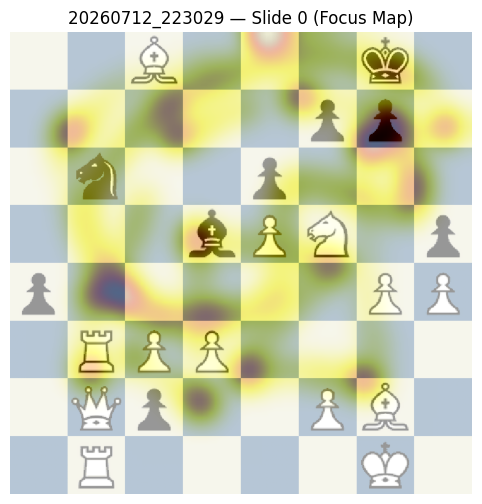

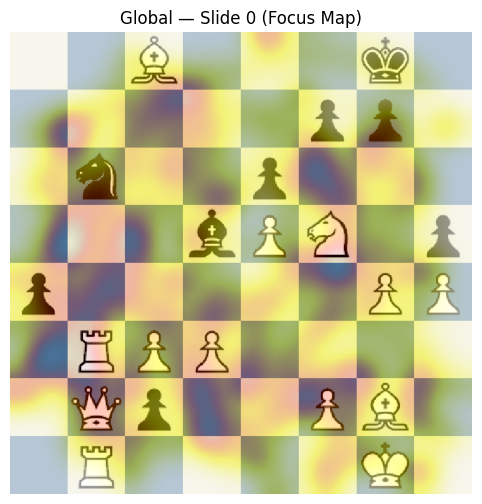

In [4]:
# --- Prepare background data ---
background_data = pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

analyzer = FocusMapAnalyzer(output_folder=output_dir)

# --- Global ---
print("▶ Global focus map statistics")
global_stats = analyzer.analyze(background_data, per="global")
display(global_stats)

# --- Set-level ---
print("▶ Per-set statistics")
set_stats = analyzer.analyze(background_data, per="set")
display(set_stats.head())

# --- Slide-level ---
print("▶ Per-slide statistics")
slide_stats = analyzer.analyze(background_data, per="slide")
display(slide_stats.head())

# ============================================================
# 🖼 Plot focus map for one example slide
# ============================================================

example_slide = background_data.iloc[0]
subset = background_data[
    (background_data["set_name"] == example_slide["set_name"]) &
    (background_data["slide_index"] == example_slide["slide_index"])
]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

# --- Focus map for single slide (individual subject) ---
analyzer.plot_analysis(
    background_data=subset,
    screenshot_path=screenshot_path,
    title=f"{example_slide['set_name']} — Slide {example_slide['slide_index']} (Focus Map)",
)

# --- Focus map using all gaze data for this slide (across subjects) ---
analyzer.plot_analysis(
    background_data=background_data,
    screenshot_path=screenshot_path,
    title=f"Global — Slide {example_slide['slide_index']} (Focus Map)",
)

▶ Detecting saccades...


,set_name,slide_index,start_time,end_time,duration,x_start,y_start,x_end,y_end,amplitude,peak_velocity,mean_velocity,mean_acceleration
0,20260712_223029,0,42.490791,42.583368,0.113099,265.796875,300.515625,237.261719,312.566406,30.975417,567.311081,298.456350,8688.629858
1,20260712_223029,0,42.624490,42.624490,0.020559,233.882812,314.554688,232.132812,315.726562,2.106132,102.445167,102.445167,4290.702941
2,20260712_223029,0,42.665566,43.652265,1.007261,224.234375,318.203125,-120.695312,253.250000,350.992020,891.693457,370.529486,8026.326988
3,20260712_223029,0,43.693352,44.547555,0.874728,-125.175781,250.406250,-195.726562,-43.945312,302.688379,1145.776482,421.912707,9408.120721
4,20260712_223029,0,44.783965,44.783965,0.020552,-185.468750,-56.277344,-184.554688,-57.191406,1.292680,62.897740,62.897740,6114.526865


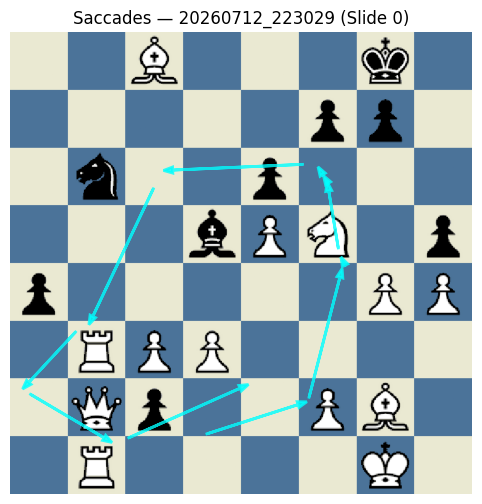

In [5]:
background_data = pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

saccade_analyzer = SaccadeAnalyzer(
    output_folder=output_dir,
    method="ivt",               # "ivt" (velocity-based) or "acceleration"
    velocity_threshold=120.0,   # pixels/sec
    acceleration_threshold=6000.0,  # pixels/sec^2
    min_duration=0.015,         # seconds
)

print("▶ Detecting saccades...")
saccades = saccade_analyzer.analyze(background_data)
display(saccades.head())

example_slide = background_data.iloc[0]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

saccade_analyzer.plot_analysis(
    saccades=saccades,
    screenshot_path=screenshot_path,
    set_name=example_slide["set_name"],
    slide_index=int(example_slide["slide_index"]) + 1,
    title=f"Saccades — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)

▶ Detecting fixations...


,fix_start,fix_end,duration,x_mean,y_mean,dispersion,set_name,slide_index
0,42.429137,42.645003,0.215867,248.516927,307.883464,64.746094,20260712_223029,0
1,42.665566,42.768303,0.102736,191.181641,325.964844,63.136719,20260712_223029,0
2,42.788939,42.933112,0.144173,123.749023,335.888672,64.000000,20260712_223029,0
3,42.953701,43.066728,0.113027,62.521763,326.100446,66.558594,20260712_223029,0
4,43.087307,43.231141,0.143834,1.273438,311.864746,65.382812,20260712_223029,0


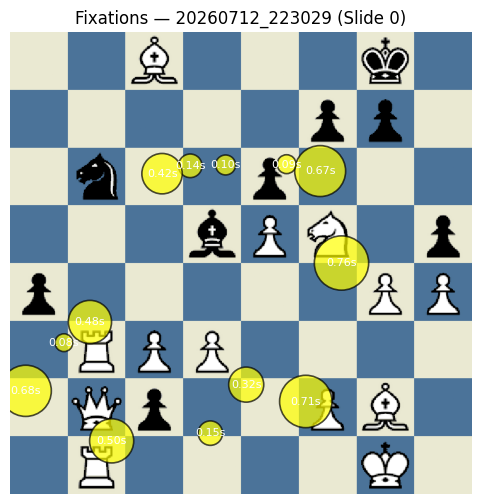

In [6]:
background_data = pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

fixation_analyzer = FixationAnalyzer(
    output_folder=output_dir,
    method="dispersion",           # or "velocity"
    dispersion_threshold=60.0,     # pixels
    min_duration=0.08,             # seconds
)

print("▶ Detecting fixations...")
fixations = fixation_analyzer.analyze(background_data)
display(fixations.head())

example_slide = background_data.iloc[0]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

fixation_analyzer.plot_analysis(
    fixations=fixations,
    screenshot_path=screenshot_path,
    set_name=example_slide["set_name"],
    slide_index=int(example_slide["slide_index"]) + 1,
    title=f"Fixations — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)

▶ Performing gaze clustering...


,set_name,slide_index,screenshot_file,input_data,classification,user_classification,model_prediction,voice_file,voice_start_timestamp,event_type,...,gaze_x_left,gaze_y_left,gaze_x_right,gaze_y_right,pupil_left,pupil_right,avg_gaze_x,avg_gaze_y,avg_pupil_size,cluster
0,20260712_223029,0,output/20260712_223029/frame_61_delay-1s.gif,datasets/chess/bad/frame_61_delay-1s.gif,bad,bad,None,NaN,NaN,MonocularEyeSampleEventNT,...,269.269531,298.492188,None,None,5,0,269.269531,298.492188,2.5,0
1,20260712_223029,0,output/20260712_223029/frame_61_delay-1s.gif,datasets/chess/bad/frame_61_delay-1s.gif,bad,bad,None,NaN,NaN,MonocularEyeSampleEventNT,...,268.347656,299.183594,None,None,5,0,268.347656,299.183594,2.5,0
2,20260712_223029,0,output/20260712_223029/frame_61_delay-1s.gif,datasets/chess/bad/frame_61_delay-1s.gif,bad,bad,None,NaN,NaN,MonocularEyeSampleEventNT,...,265.796875,300.515625,None,None,5,0,265.796875,300.515625,2.5,0
3,20260712_223029,0,output/20260712_223029/frame_61_delay-1s.gif,datasets/chess/bad/frame_61_delay-1s.gif,bad,bad,None,NaN,NaN,MonocularEyeSampleEventNT,...,263.292969,301.917969,None,None,5,0,263.292969,301.917969,2.5,0
4,20260712_223029,0,output/20260712_223029/frame_61_delay-1s.gif,datasets/chess/bad/frame_61_delay-1s.gif,bad,bad,None,NaN,NaN,MonocularEyeSampleEventNT,...,256.148438,304.734375,None,None,5,0,256.148438,304.734375,2.5,0


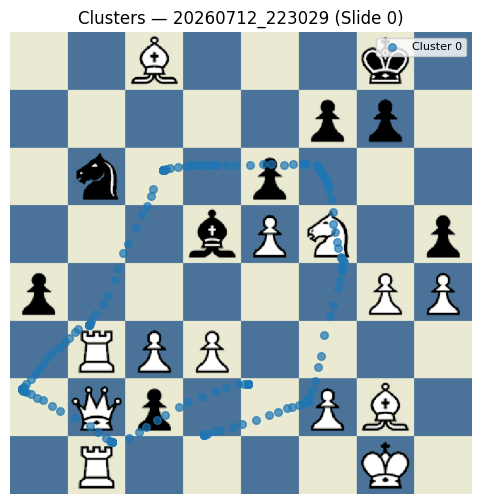

In [7]:
# ==============================================
# 👁️ Cluster Analyzer Demo
# ==============================================
from pathlib import Path
import pandas as pd

background_data= pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

# Instantiate analyzer (DBSCAN by default)
cluster_analyzer = ClusterAnalyzer(
    output_folder=output_dir,
    eps=20,              # pixel distance for clustering
    min_samples=3,        # minimum points per cluster
)

print("▶ Performing gaze clustering...")
clustered_data = cluster_analyzer.analyze(background_data)
display(clustered_data.head())

# --- Visualization for one slide ---
example_slide = background_data.iloc[0]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

cluster_analyzer.plot_analysis(
    background_data=clustered_data,
    screenshot_path=screenshot_path,
    set_name=example_slide["set_name"],
    slide_index=int(example_slide["slide_index"]) + 1,
    title=f"Clusters — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)

▶ Slide-level entropy


,entropy,convex_hull_area,num_points,set_name,slide_index
0,8.300678,289101.811432,603,20260712_223029,0
1,5.979818,166330.040215,232,20260712_223029,1
2,7.212748,212998.086273,292,20260712_223029,2
3,7.042560,277835.123650,329,20260712_223029,3
4,6.964289,229576.650803,200,20260712_223029,4


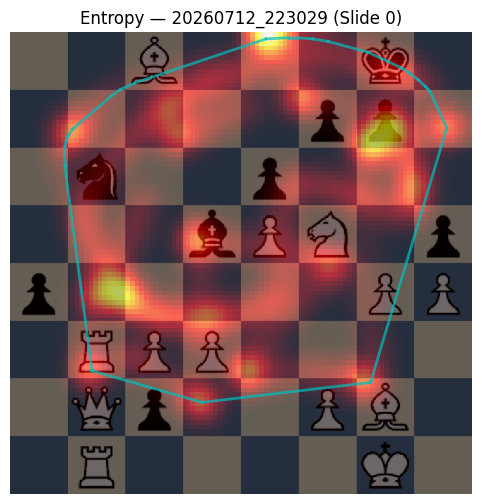

In [8]:
# ==============================================
# 🧠 Entropy Analyzer Demo
# ==============================================
background_data = pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

entropy_analyzer = EntropyAnalyzer(output_folder=output_dir)

print("▶ Slide-level entropy")
entropy_results = entropy_analyzer.analyze(background_data, per="slide", bins=100, use_convex_hull=True)
display(entropy_results.head())

# --- Visualization for one example slide ---
example_slide = background_data.iloc[0]
subset = background_data[
    (background_data["set_name"] == example_slide["set_name"]) &
    (background_data["slide_index"] == example_slide["slide_index"])
]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

entropy_analyzer.plot_analysis(
    background_data=subset,
    screenshot_path=screenshot_path,
    title=f"Entropy — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)


▶ Loading raw and flattened experiment data
Raw rows: 10
Gaze rows: 2870


,set_name,screenshot_file,input_data,classification,user_classification,gaze_data,objects_bboxes,voice_file,voice_start_timestamp,slide_index
0,20260712_223029,output/20260712_223029/frame_61_delay-1s.gif,datasets/chess/bad/frame_61_delay-1s.gif,bad,bad,"[{'event_type': 'MonocularEyeSampleEventNT', '...","{'image_bboxes': [{'class': 'superpixel', 'con...",NaN,NaN,0
1,20260712_223029,output/20260712_223029/frame_01_delay-1s.gif,datasets/chess/good/frame_01_delay-1s.gif,good,good,"[{'event_type': 'MonocularEyeSampleEventNT', '...","{'image_bboxes': [{'class': 'superpixel', 'con...",NaN,NaN,1
2,20260712_223029,output/20260712_223029/frame_33_delay-1s.gif,datasets/chess/good/frame_33_delay-1s.gif,good,bad,"[{'event_type': 'MonocularEyeSampleEventNT', '...","{'image_bboxes': [{'class': 'superpixel', 'con...",NaN,NaN,2
3,20260712_223029,output/20260712_223029/frame_03_delay-1s.gif,datasets/chess/good/frame_03_delay-1s.gif,good,good,"[{'event_type': 'MonocularEyeSampleEventNT', '...","{'image_bboxes': [{'class': 'superpixel', 'con...",NaN,NaN,3
4,20260712_223029,output/20260712_223029/frame_30_delay-1s.gif,datasets/chess/good/frame_30_delay-1s.gif,good,none,"[{'event_type': 'MonocularEyeSampleEventNT', '...","{'image_bboxes': [{'class': 'superpixel', 'con...",NaN,NaN,4


,set_name,slide_index,screenshot_file,input_data,classification,user_classification,model_prediction,voice_file,voice_start_timestamp,event_type,...,system_time,gaze_x_left,gaze_y_left,gaze_x_right,gaze_y_right,pupil_left,pupil_right,avg_gaze_x,avg_gaze_y,avg_pupil_size
0,20260712_223029,0,output/20260712_223029/frame_61_delay-1s.gif,datasets/chess/bad/frame_61_delay-1s.gif,bad,bad,None,NaN,NaN,MonocularEyeSampleEventNT,...,42.429137,269.269531,298.492188,None,None,5,0,269.269531,298.492188,2.5
1,20260712_223029,0,output/20260712_223029/frame_61_delay-1s.gif,datasets/chess/bad/frame_61_delay-1s.gif,bad,bad,None,NaN,NaN,MonocularEyeSampleEventNT,...,42.449751,268.347656,299.183594,None,None,5,0,268.347656,299.183594,2.5
2,20260712_223029,0,output/20260712_223029/frame_61_delay-1s.gif,datasets/chess/bad/frame_61_delay-1s.gif,bad,bad,None,NaN,NaN,MonocularEyeSampleEventNT,...,42.470268,265.796875,300.515625,None,None,5,0,265.796875,300.515625,2.5
3,20260712_223029,0,output/20260712_223029/frame_61_delay-1s.gif,datasets/chess/bad/frame_61_delay-1s.gif,bad,bad,None,NaN,NaN,MonocularEyeSampleEventNT,...,42.490791,263.292969,301.917969,None,None,5,0,263.292969,301.917969,2.5
4,20260712_223029,0,output/20260712_223029/frame_61_delay-1s.gif,datasets/chess/bad/frame_61_delay-1s.gif,bad,bad,None,NaN,NaN,MonocularEyeSampleEventNT,...,42.511330,256.148438,304.734375,None,None,5,0,256.148438,304.734375,2.5


▶ Mapping gaze points to generated bboxes


,set_name,slide_index,screenshot_file,input_data,bbox_index,bbox_class,bbox_conf,cx,cy,w,h,total_gaze_points,hit_count,coverage,dwell_time,attention_score,attention_rank
0,20260712_223029,0,output/20260712_223029/frame_61_delay-1s.gif,datasets/chess/bad/frame_61_delay-1s.gif,0,superpixel,1.0,-328.12500,328.125,93.7500,93.75,603,0,0.000000,0.0,0.000000,24
1,20260712_223029,0,output/20260712_223029/frame_61_delay-1s.gif,datasets/chess/bad/frame_61_delay-1s.gif,1,superpixel,1.0,-234.37500,328.125,93.7500,93.75,603,1,0.001658,1.0,0.001658,23
2,20260712_223029,0,output/20260712_223029/frame_61_delay-1s.gif,datasets/chess/bad/frame_61_delay-1s.gif,2,superpixel,1.0,-124.21875,328.125,126.5625,93.75,603,8,0.013267,8.0,0.013267,17
3,20260712_223029,0,output/20260712_223029/frame_61_delay-1s.gif,datasets/chess/bad/frame_61_delay-1s.gif,3,superpixel,1.0,-31.25000,328.125,62.5000,93.75,603,12,0.019900,12.0,0.019900,14
4,20260712_223029,0,output/20260712_223029/frame_61_delay-1s.gif,datasets/chess/bad/frame_61_delay-1s.gif,4,superpixel,1.0,46.87500,328.125,93.7500,93.75,603,31,0.051410,31.0,0.051410,7


Generated bbox score rows: 391
▶ Evaluating bbox/gaze mapping quality


,set_name,slide_index,bbox_count,attended_bboxes,attended_bbox_ratio,total_gaze_points,bbox_hit_count,coverage_by_bboxes,max_attention_score,mean_attention_score
7,20260712_223029,7,38,28,0.736842,272,395,1.452206,0.316176,0.038216
5,20260712_223029,5,36,20,0.555556,219,313,1.429224,0.388128,0.039701
1,20260712_223029,1,34,15,0.441176,232,312,1.344828,0.267241,0.039554
4,20260712_223029,4,38,20,0.526316,200,246,1.230000,0.135000,0.032368
3,20260712_223029,3,36,24,0.666667,329,388,1.179331,0.139818,0.032759
8,20260712_223029,8,43,22,0.511628,151,174,1.152318,0.172185,0.026798
2,20260712_223029,2,39,24,0.615385,292,332,1.136986,0.150685,0.029153
9,20260712_223029,9,45,27,0.600000,269,303,1.126394,0.107807,0.025031
0,20260712_223029,0,42,32,0.761905,603,663,1.099502,0.152570,0.026179
6,20260712_223029,6,40,25,0.625000,303,333,1.099010,0.158416,0.027475


▶ Visualizing attended bboxes on screenshot


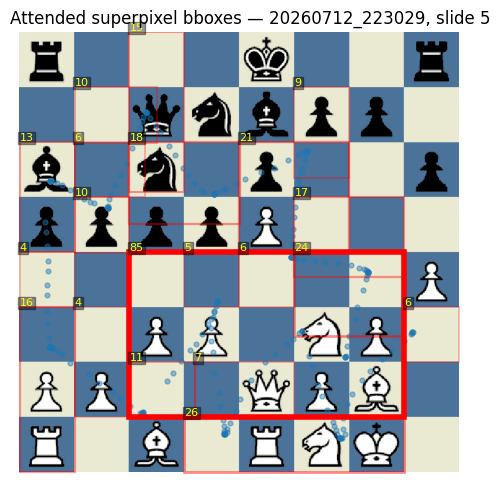

,set_name,slide_index,bbox_count,attended_bboxes,attended_bbox_ratio,total_gaze_points,bbox_hit_count,coverage_by_bboxes,max_attention_score,mean_attention_score
0,20260712_223029,0,42,25,0.595238,54,62,1.148148,0.129630,0.027337
1,20260712_223029,1,34,8,0.235294,13,17,1.307692,0.307692,0.038462
2,20260712_223029,2,39,16,0.410256,23,29,1.260870,0.217391,0.032330
3,20260712_223029,3,36,19,0.527778,26,31,1.192308,0.153846,0.033120
4,20260712_223029,4,38,15,0.394737,16,20,1.250000,0.187500,0.032895


In [9]:
from pathlib import Path
import pandas as pd

print("▶ Loading raw and flattened experiment data")

raw_data = pd.concat(
    loader.get_all_data(flatten=False).values(),
    keys=loader.get_all_data(flatten=False).keys(),
    names=["set_name", "row_index"],
).reset_index(level="set_name")

raw_data = raw_data.reset_index(drop=True)

# Make slide_index explicit and consistent with DataLoader flattening
raw_data["slide_index"] = raw_data.groupby("set_name").cumcount()

gaze_data = pd.concat(
    loader.get_all_data(flatten=True).values(),
    ignore_index=True,
)

print("Raw rows:", len(raw_data))
print("Gaze rows:", len(gaze_data))

display(raw_data.head())
display(gaze_data.head())


output_dir = Path("./analysis_outputs")

bbox_analyzer = BBoxAttentionAnalyzer(output_folder=output_dir)

print("▶ Mapping gaze points to generated bboxes")

bbox_scores = bbox_analyzer.analyze(
    raw_data=raw_data,
    gaze_data=gaze_data,
    use_fixations=False,
)

display(bbox_scores.head())
print("Generated bbox score rows:", len(bbox_scores))

print("▶ Evaluating bbox/gaze mapping quality")

bbox_eval = bbox_analyzer.evaluate(bbox_scores)

display(bbox_eval.sort_values(
    ["coverage_by_bboxes", "attended_bbox_ratio"],
    ascending=False,
).head(20))

print("▶ Visualizing attended bboxes on screenshot")

# Select a slide that actually has gaze hits and bboxes
example = (
    bbox_scores[bbox_scores["hit_count"] > 0]
    .sort_values("attention_score", ascending=False)
    .iloc[0]
)

set_name = example["set_name"]
slide_index = int(example["slide_index"])

example_slide = raw_data[
    (raw_data["set_name"].astype(str) == str(set_name))
    & (raw_data["slide_index"].astype(int) == slide_index)
].iloc[0]

screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

bbox_analyzer.plot_analysis(
    scored_bboxes=bbox_scores,
    gaze_data=gaze_data,
    screenshot_path=screenshot_path,
    set_name=set_name,
    slide_index=slide_index,
    top_k=25,
    min_hits=1,
    title=f"Attended superpixel bboxes — {set_name}, slide {slide_index}",
    save_path=output_dir / f"bbox_attention_{set_name}_slide_{slide_index}.png",
)

fixations = fixation_analyzer.analyze(background_data)


bbox_fixation_scores = bbox_analyzer.analyze(
    raw_data=raw_data,
    gaze_data=fixations.rename(columns={
        "x_mean": "x_mean",
        "y_mean": "y_mean",
    }),
    use_fixations=True,
)

bbox_fixation_eval = bbox_analyzer.evaluate(bbox_fixation_scores)

display(bbox_fixation_eval.head())